### **Prompt Optimizer**

In [1]:
! pip install langchain_core langchain-openai langgraph langchain-nvidia-ai-endpoints


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.8 MB/s eta 0:00:00
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.14.1
    Uninstalling aiohttp-3.14.1:
      Successfully uninstalled aiohttp-3.14.1


In [2]:
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from typing_extensions import Literal
from typing import Annotated, List


In [10]:
class State(TypedDict):
  topic:str
  generated_prompt:str
  feedback:str
  great_or_not:str

In [3]:
class Feedback(BaseModel):
    grade: Literal["GOOD", "NOT GOOD"] = Field(
        description="Decide if the prompt is great or not.",
    )
    feedback: str = Field(
        description="If the prompt is not great, provide feedback on how to improve it.",
    )

In [7]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA
import os

llm = ChatNVIDIA(model=os.getenv("LLM_MODEL"),api_key=os.getenv("LLM_API_KEY"))

evaluator = llm.with_structured_output(Feedback)

In [11]:
def llm_call_generator(state: State):
    """LLM generates a prompt"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a prompt about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a prompt about {state['topic']}")
    return {"generated_prompt": msg.content}

In [15]:
def llm_evaluator(state:State):
  """LLM evaluate a prompt"""

  msg = evaluator.invoke(f"evaluate {state['generated_prompt']}")
  if msg is None:
      # Handle the case where the evaluator returns None,
      # perhaps due to an API error or inability to generate structured output.
      # For now, we'll return a default 'NOT GOOD' feedback.
      print("Warning: Evaluator returned None. Returning default 'NOT GOOD' feedback.")
      return {"great_or_not": "NOT GOOD", "feedback": "Evaluator failed to provide feedback. Check API key or model availability."}
  return {"great_or_not": msg.grade, "feedback": msg.feedback}

In [13]:
def route_prompt(state: State):
    """Route back to prompt generator or end based upon feedback from the evaluator"""

    if state["great_or_not"] == "GOOD":
        return "Accepted"
    elif state["great_or_not"] == "NOT GOOD":
        return "Rejected + Feedback"

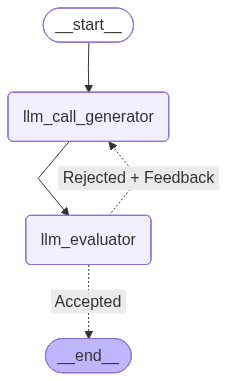

**Prompt: “Write an Image Prompt”**

As an AI developer or creative writer, you often need to craft the perfect description for an AI‑driven art generator (Midjourney, DALL·E, Stable Diffusion, etc.).  
Your task is to produce a **complete, vivid, and versatile “image prompt”** that could be fed directly into such a system.

**Requirements:**

1. **Subject & Composition**  
   - Choose a single dominant subject (person, animal, object, landscape, or scene).  
   - State its primary pose or action.  
   - Indicate the viewpoint or camera angle (e.g., "bird’s‑eye view", "widows‑eye height").

2. **Setting & Atmosphere**  
   - Describe the environment (indoor/outdoor, time of day, season, weather).  
   - Mention any surrounding elements that contribute to mood (e.g., misty forest, neon‑lit alley).

3. **Lighting & Color**  
   - Specify the light source (natural sunlight, golden hour, back‑lighting, studio lights).  
   - Provide a color palette or dominant hues (pastel, monochrome, vib

In [16]:
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_evaluator", llm_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_evaluator",
    route_prompt,
    {
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = optimizer_workflow.invoke({"topic": "Write image prompt"})
print(state["generated_prompt"])